# Compare two optimization paths

- **Method A**: Optimize starting from `sample/reconstructed_mols_no_opt/F.Mec.q.Y.pickle` conformer coords (what `plot_optimization_trajectory_nglview.ipynb` does)
- **Method B**: Full production reconstruction+optimization from `sample/samples.pickle` at index 827 (`reconstruct_single.py` logic with `skip_opt=False`)

In [ ]:
import json
import pickle
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from scipy.optimize import NonlinearConstraint, minimize

from ringer.utils import internal_coords, reconstruction
from ringer.utils.internal_coords import (
    compute_canonical_transform,
    apply_affine_transform,
    angle_and_dihedral_loss,
)

In [2]:
ROOT = Path.cwd()
if not (ROOT / "ringer").exists():
    ROOT = ROOT.parent

MOL_NAME = "F.Mec.q.Y.pickle"
MOL_IDX = 827

PRE_OPT_PATH = ROOT / "sample/reconstructed_mols_no_opt" / MOL_NAME
TEST_MOL_DIR = ROOT / "data/cremp/test"
SAMPLES_PATH = ROOT / "sample/samples.pickle"
MEAN_DIST_PATH = ROOT / "assets/models/conditional/training_mean_distances.json"

MAX_CONF: Optional[int] = 32
MAXITER = 100

for p in [PRE_OPT_PATH, SAMPLES_PATH, MEAN_DIST_PATH]:
    assert p.exists(), p
print(ROOT)

/mnt/HDD1/Codes/ringer


In [3]:
def _load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)


def _kabsch_rmsd(ref_xyz: np.ndarray, probe_xyz: np.ndarray) -> float:
    ref = np.asarray(ref_xyz, dtype=float)
    probe = np.asarray(probe_xyz, dtype=float)
    ref_centered = ref - ref.mean(axis=0)
    probe_centered = probe - probe.mean(axis=0)
    cov = probe_centered.T @ ref_centered
    u, _, vt = np.linalg.svd(cov)
    sign = np.sign(np.linalg.det(u @ vt))
    rot = u @ np.diag([1.0, 1.0, sign]) @ vt
    probe_aligned = probe_centered @ rot
    return float(np.sqrt(np.mean(np.sum((probe_aligned - ref_centered) ** 2, axis=1))))

In [ ]:
# Load structure from samples.pickle at index 827 (same as reconstruct_single.py)
structures_dict = _load_pickle(SAMPLES_PATH)
fname = list(structures_dict.keys())[MOL_IDX]
assert (
    Path(fname).name == MOL_NAME
), f"Index {MOL_IDX} is {Path(fname).name}, not {MOL_NAME}"
structure = structures_dict[fname]

with MEAN_DIST_PATH.open("r") as f:
    mean_bond_dists = json.load(f)

# Load test mol (needed for Method B production reconstruction)
test_mol_path = TEST_MOL_DIR / MOL_NAME
assert test_mol_path.exists(), test_mol_path
test_mol = _load_pickle(test_mol_path)
if isinstance(test_mol, dict):
    test_mol = test_mol["rd_mol"]

# Load pre_mol (needed for Method A)
pre_mol = _load_pickle(PRE_OPT_PATH)

ring_idxs = list(structure["dihedral"].columns)
ring_internal = internal_coords.RingInternalCoordinates(ring_idxs)
bond_dists = pd.Series(
    data=(mean_bond_dists[label] for label in structure["atom_labels"]),
    index=ring_idxs,
    dtype=float,
)

n_conf_samples = len(structure["dihedral"])
n_conf_premol = pre_mol.GetNumConformers()
n_conf = min(n_conf_samples, n_conf_premol)
if MAX_CONF is not None:
    n_conf = min(MAX_CONF, n_conf)
conf_indices = list(range(n_conf))

print(f"Molecule: {MOL_NAME} (index {MOL_IDX})")
print(f"Ring atoms: {len(ring_idxs)}")
print(f"Conformers in samples: {n_conf_samples}")
print(f"Conformers in pre_mol: {n_conf_premol}")
print(f"Running: {len(conf_indices)}")

Molecule: F.Mec.q.Y.pickle (index 827)
Ring atoms: 12
Conformers in samples: 2756
Conformers in pre_mol: 2756
Running: 32


In [5]:
@dataclass
class TrajectoryResult:
    conf_idx: int
    success: bool
    niter: int
    message: str
    objective: List[float]
    ring_xyz_frames: List[np.ndarray]
    final_xyz: np.ndarray

## Method A: Optimize from `reconstructed_mols_no_opt` conformers

Uses pre_mol conformer ring coords as x0, then optimizes. Same as `plot_optimization_trajectory_nglview.ipynb`.

In [ ]:
def optimize_from_premol(
    pre_mol: Chem.Mol,
    conf_idx: int,
) -> TrajectoryResult:
    angle_target = structure["angle"].loc[conf_idx]
    dihedral_target = structure["dihedral"].loc[conf_idx]

    xyz0_raw = pre_mol.GetConformer(conf_idx).GetPositions()[ring_idxs]
    trans_mat = compute_canonical_transform(xyz0_raw)
    inv_trans = np.linalg.inv(trans_mat)
    x0 = apply_affine_transform(xyz0_raw, trans_mat).ravel()

    objective: List[float] = []
    x_frames: List[np.ndarray] = [x0.copy()]

    def objective_with_grad(x: np.ndarray):
        loss, grad = angle_and_dihedral_loss(
            x,
            internal_coords=ring_internal,
            angle_vals_target=np.asarray(angle_target),
            dihedral_vals_target=np.asarray(dihedral_target),
            grad=True,
        )
        objective.append(float(loss))
        return loss, grad

    dist_constraint = NonlinearConstraint(
        ring_internal.compute_distances,
        lb=np.asarray(bond_dists),
        ub=np.asarray(bond_dists),
        jac=ring_internal.compute_distance_jacobian,
    )

    def callback(xk: np.ndarray, *args):
        x_frames.append(np.asarray(xk).copy())

    result = minimize(
        objective_with_grad,
        x0,
        constraints=[dist_constraint],
        jac=True,
        options={"maxiter": MAXITER},
        callback=callback,
    )

    if not np.allclose(x_frames[-1], result.x):
        x_frames.append(np.asarray(result.x).copy())

    ring_xyz_frames = [
        apply_affine_transform(x.reshape(-1, 3), inv_trans) for x in x_frames
    ]

    return TrajectoryResult(
        conf_idx=int(conf_idx),
        success=bool(result.success),
        niter=int(getattr(result, "nit", len(x_frames) - 1)),
        message=str(result.message),
        objective=objective,
        ring_xyz_frames=ring_xyz_frames,
        final_xyz=ring_xyz_frames[-1],
    )


results_A: Dict[int, TrajectoryResult] = {}
for conf_idx in conf_indices:
    results_A[conf_idx] = optimize_from_premol(pre_mol, conf_idx)

print(
    f"Method A: {sum(r.success for r in results_A.values())}/{len(results_A)} successful"
)

Method A: 32/32 successful


## Method B: Full production reconstruction from `samples.pickle`

Calls `reconstruction.reconstruct_ring(skip_opt=False)` exactly as `reconstruct_single.py` does at index 827.
Then also replicates with trajectory capture.

In [7]:
# Run production reconstruct_ring (no trajectory, just final result)
mol_B, coords_B, unsuccessful_B = reconstruction.reconstruct_ring(
    mol=deepcopy(test_mol),
    structure=structure,
    bond_dist_dict=mean_bond_dists,
    angles_as_constraints=False,
    opt_init="average",
    skip_opt=False,
    drop_unsuccessful=True,
    max_conf=MAX_CONF,
    return_unsuccessful=True,
    ncpu=1,
)

print(f"Method B production: {mol_B.GetNumConformers()} conformers reconstructed")
print(f"Unsuccessful: {len(unsuccessful_B)}")

  0%|          | 0/32 [00:00<?, ?it/s]

Method B production: 32 conformers reconstructed
Unsuccessful: 0


In [ ]:
# Replicate production path with trajectory capture
def production_with_trajectory(conf_idx: int) -> TrajectoryResult:
    angle_target = structure["angle"].loc[conf_idx]
    dihedral_target = structure["dihedral"].loc[conf_idx]

    # Get production x0 via to_cartesian(skip_opt=True)
    mol_copy = deepcopy(test_mol)
    coords_init, _ = ring_internal.to_cartesian(
        mol=mol_copy,
        distance_vals=bond_dists,
        angle_vals_target=angle_target,
        dihedral_vals_target=dihedral_target,
        skip_opt=True,
        return_result_obj=True,
    )
    xyz0_raw = coords_init[["x", "y", "z"]].values

    trans_mat = compute_canonical_transform(xyz0_raw)
    inv_trans = np.linalg.inv(trans_mat)
    x0 = apply_affine_transform(xyz0_raw, trans_mat).ravel()

    objective: List[float] = []
    x_frames: List[np.ndarray] = [x0.copy()]

    def objective_with_grad(x: np.ndarray):
        loss, grad = angle_and_dihedral_loss(
            x,
            internal_coords=ring_internal,
            angle_vals_target=np.asarray(angle_target),
            dihedral_vals_target=np.asarray(dihedral_target),
            grad=True,
        )
        objective.append(float(loss))
        return loss, grad

    dist_constraint = NonlinearConstraint(
        ring_internal.compute_distances,
        lb=np.asarray(bond_dists),
        ub=np.asarray(bond_dists),
        jac=ring_internal.compute_distance_jacobian,
    )

    def callback(xk: np.ndarray, *args):
        x_frames.append(np.asarray(xk).copy())

    result = minimize(
        objective_with_grad,
        x0,
        constraints=[dist_constraint],
        jac=True,
        options={"maxiter": MAXITER},
        callback=callback,
    )

    if not np.allclose(x_frames[-1], result.x):
        x_frames.append(np.asarray(result.x).copy())

    ring_xyz_frames = [
        apply_affine_transform(x.reshape(-1, 3), inv_trans) for x in x_frames
    ]

    return TrajectoryResult(
        conf_idx=int(conf_idx),
        success=bool(result.success),
        niter=int(getattr(result, "nit", len(x_frames) - 1)),
        message=str(result.message),
        objective=objective,
        ring_xyz_frames=ring_xyz_frames,
        final_xyz=ring_xyz_frames[-1],
    )


results_B: Dict[int, TrajectoryResult] = {}
for conf_idx in conf_indices:
    results_B[conf_idx] = production_with_trajectory(conf_idx)

print(
    f"Method B trajectories: {sum(r.success for r in results_B.values())}/{len(results_B)} successful"
)

Method B trajectories: 32/32 successful


## Verify trajectory replay matches `reconstruct_ring` output

In [ ]:
# reconstruct_ring returns coords in canonical frame (no inverse transform).
# Our trajectory captures apply inverse transform. Compare via internal coords.
verify_rows = []
successful_conf_indices = [ci for ci in conf_indices if ci not in unsuccessful_B]
for i, conf_idx in enumerate(successful_conf_indices):
    prod_ring = mol_B.GetConformer(i).GetPositions()[ring_idxs]
    traj_ring = results_B[conf_idx].final_xyz

    prod_angles = ring_internal.compute_angles(prod_ring.ravel())
    traj_angles = ring_internal.compute_angles(traj_ring.ravel())
    prod_dihedrals = ring_internal.compute_dihedrals(prod_ring.ravel())
    traj_dihedrals = ring_internal.compute_dihedrals(traj_ring.ravel())

    verify_rows.append(
        {
            "conf_idx": conf_idx,
            "angle_max_diff": np.max(np.abs(prod_angles - traj_angles)),
            "dihedral_max_diff": np.max(np.abs(prod_dihedrals - traj_dihedrals)),
        }
    )

verify_df = pd.DataFrame(verify_rows)
print("Max angle/dihedral diff between reconstruct_ring and trajectory replay:")
print(verify_df[["angle_max_diff", "dihedral_max_diff"]].describe())

Max angle/dihedral diff between reconstruct_ring and trajectory replay:
       angle_max_diff  dihedral_max_diff
count       32.000000          32.000000
mean         0.497802           5.896207
std          0.479101           0.506235
min          0.000122           4.686040
25%          0.000269           5.766713
50%          0.707185           6.172106
75%          0.809066           6.195173
max          1.386505           6.263618


## Compare Method A vs Method B

In [ ]:
rows = []
for conf_idx in conf_indices:
    ra = results_A[conf_idx]
    rb = results_B[conf_idx]

    x0_rmsd = _kabsch_rmsd(ra.ring_xyz_frames[0], rb.ring_xyz_frames[0])
    final_rmsd = _kabsch_rmsd(ra.final_xyz, rb.final_xyz)

    rows.append(
        {
            "conf_idx": conf_idx,
            "x0_rmsd": x0_rmsd,
            "final_rmsd": final_rmsd,
            "A_niter": ra.niter,
            "B_niter": rb.niter,
            "A_obj_final": ra.objective[-1] if ra.objective else np.nan,
            "B_obj_final": rb.objective[-1] if rb.objective else np.nan,
            "A_success": ra.success,
            "B_success": rb.success,
        }
    )

cmp_df = pd.DataFrame(rows)
cmp_df

,conf_idx,x0_rmsd,final_rmsd,A_niter,B_niter,A_obj_final,B_obj_final,A_success,B_success
0,0,0.280538,1.110610,19,34,0.255534,5.118612,True,True
1,1,0.309014,1.077401,18,35,0.306432,5.079037,True,True
2,2,0.233436,0.902187,18,28,0.179128,0.179128,True,True
3,3,0.355565,1.053606,21,33,0.369212,5.174064,True,True
4,4,0.349183,0.886524,19,29,0.387890,0.387890,True,True
5,5,0.253148,1.139999,20,35,0.218543,5.261174,True,True
6,6,0.311616,0.877698,18,30,0.319677,0.319677,True,True
7,7,0.449054,0.924138,19,27,0.614115,0.614115,True,True
8,8,0.319167,1.099503,20,33,0.289231,5.233779,True,True
9,9,0.308102,1.089176,18,36,0.303324,5.300068,True,True


In [11]:
print("=== x0 RMSD: A (pre_mol) vs B (production init) ===")
print(cmp_df["x0_rmsd"].describe())
print()
print("=== Final RMSD: A vs B ===")
print(cmp_df["final_rmsd"].describe())
print()
print("=== Final objective A (pre_mol) ===")
print(cmp_df["A_obj_final"].describe())
print()
print("=== Final objective B (production) ===")
print(cmp_df["B_obj_final"].describe())

=== x0 RMSD: A (pre_mol) vs B (production init) ===
count    32.000000
mean      0.281178
std       0.072690
min       0.018549
25%       0.237943
50%       0.290720
75%       0.329219
max       0.449054
Name: x0_rmsd, dtype: float64

=== Final RMSD: A vs B ===
count    32.000000
mean      1.023993
std       0.245522
min       0.000308
25%       0.894829
50%       1.060804
75%       1.140388
max       1.350199
Name: final_rmsd, dtype: float64

=== Final objective A (pre_mol) ===
count    32.000000
mean      0.433151
std       0.874997
min       0.149920
25%       0.199369
50%       0.289016
75%       0.340703
max       5.200088
Name: A_obj_final, dtype: float64

=== Final objective B (production) ===
count    32.000000
mean      3.534192
std       2.566646
min       0.179128
25%       0.353984
50%       5.146338
75%       5.267612
max       6.519750
Name: B_obj_final, dtype: float64


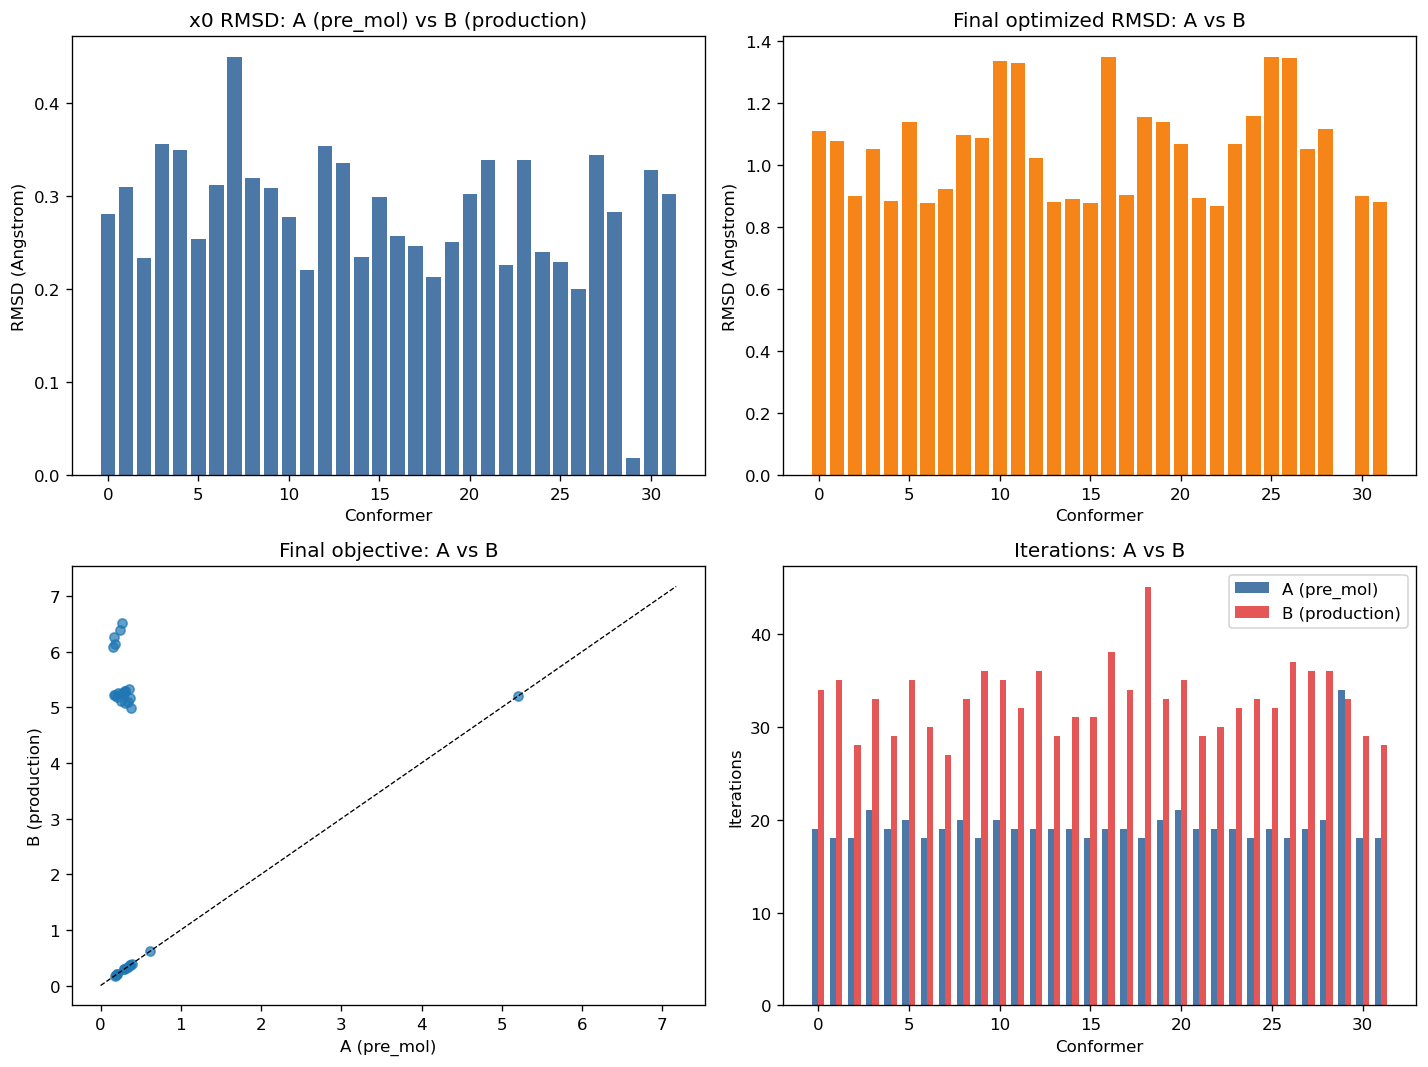

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=120)

axes[0, 0].bar(cmp_df["conf_idx"], cmp_df["x0_rmsd"], color="#4C78A8")
axes[0, 0].set_title("x0 RMSD: A (pre_mol) vs B (production)")
axes[0, 0].set_xlabel("Conformer")
axes[0, 0].set_ylabel("RMSD (Angstrom)")

axes[0, 1].bar(cmp_df["conf_idx"], cmp_df["final_rmsd"], color="#F58518")
axes[0, 1].set_title("Final optimized RMSD: A vs B")
axes[0, 1].set_xlabel("Conformer")
axes[0, 1].set_ylabel("RMSD (Angstrom)")

axes[1, 0].scatter(cmp_df["A_obj_final"], cmp_df["B_obj_final"], alpha=0.7, s=30)
lim = max(cmp_df["A_obj_final"].max(), cmp_df["B_obj_final"].max()) * 1.1
axes[1, 0].plot([0, lim], [0, lim], "k--", lw=0.8)
axes[1, 0].set_title("Final objective: A vs B")
axes[1, 0].set_xlabel("A (pre_mol)")
axes[1, 0].set_ylabel("B (production)")

x = np.arange(len(cmp_df))
w = 0.35
axes[1, 1].bar(x - w / 2, cmp_df["A_niter"], w, label="A (pre_mol)", color="#4C78A8")
axes[1, 1].bar(x + w / 2, cmp_df["B_niter"], w, label="B (production)", color="#E45756")
axes[1, 1].set_title("Iterations: A vs B")
axes[1, 1].set_xlabel("Conformer")
axes[1, 1].set_ylabel("Iterations")
axes[1, 1].legend()

plt.tight_layout()

## Per-conformer trajectory comparison

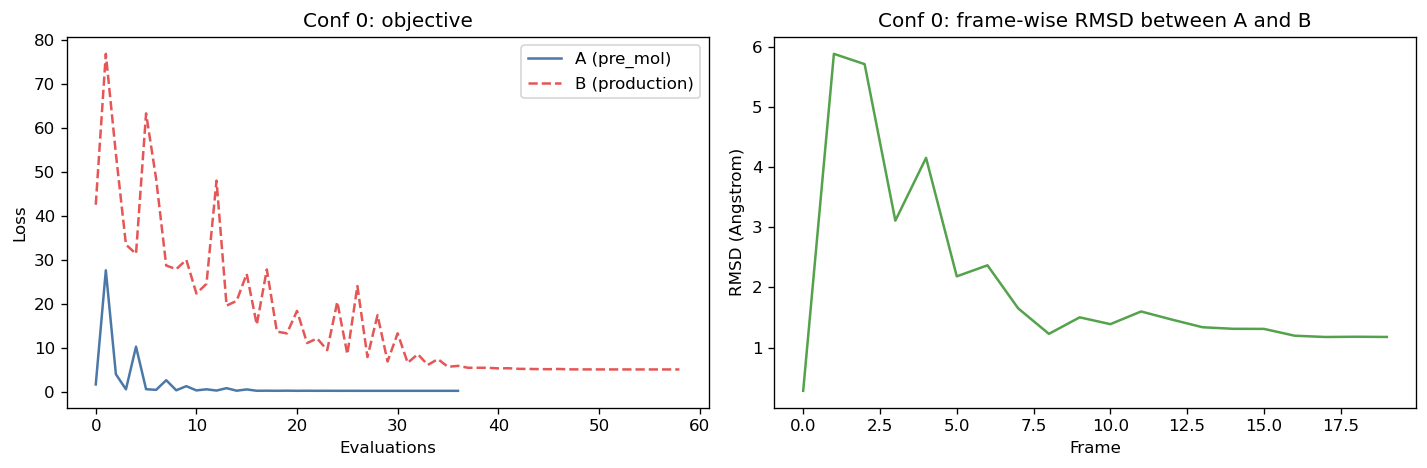

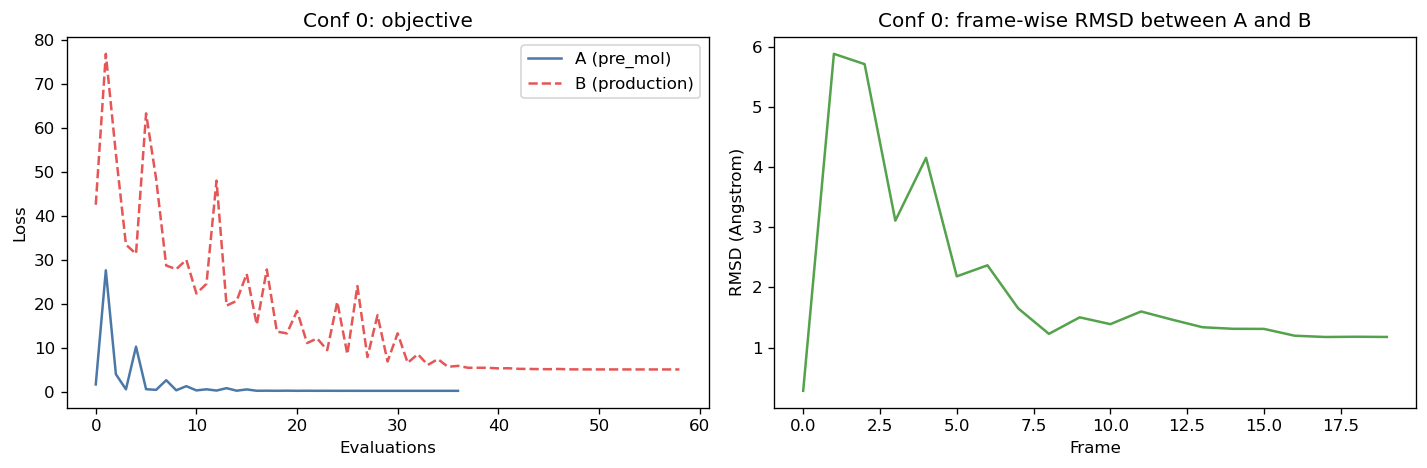

In [13]:
def plot_trajectory_comparison(conf_idx: int):
    ra = results_A[conf_idx]
    rb = results_B[conf_idx]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

    axes[0].plot(ra.objective, label="A (pre_mol)", color="#4C78A8")
    axes[0].plot(rb.objective, label="B (production)", color="#E45756", linestyle="--")
    axes[0].set_title(f"Conf {conf_idx}: objective")
    axes[0].set_xlabel("Evaluations")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    min_len = min(len(ra.ring_xyz_frames), len(rb.ring_xyz_frames))
    rmsd_ab = [
        _kabsch_rmsd(ra.ring_xyz_frames[i], rb.ring_xyz_frames[i])
        for i in range(min_len)
    ]
    axes[1].plot(range(min_len), rmsd_ab, color="#54A24B")
    axes[1].set_title(f"Conf {conf_idx}: frame-wise RMSD between A and B")
    axes[1].set_xlabel("Frame")
    axes[1].set_ylabel("RMSD (Angstrom)")

    plt.tight_layout()
    return fig


plot_trajectory_comparison(0)

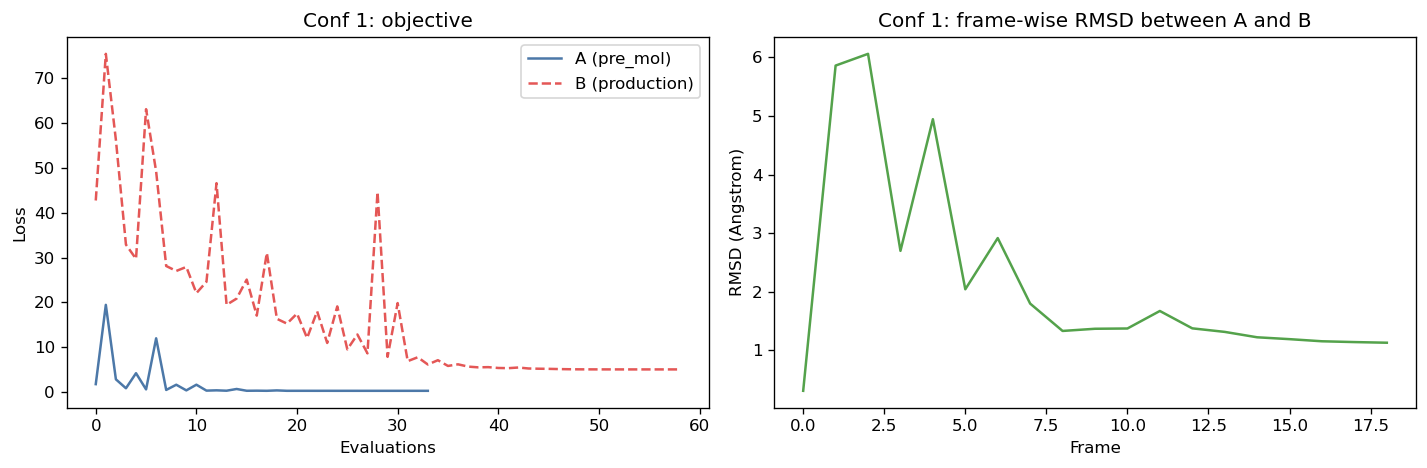

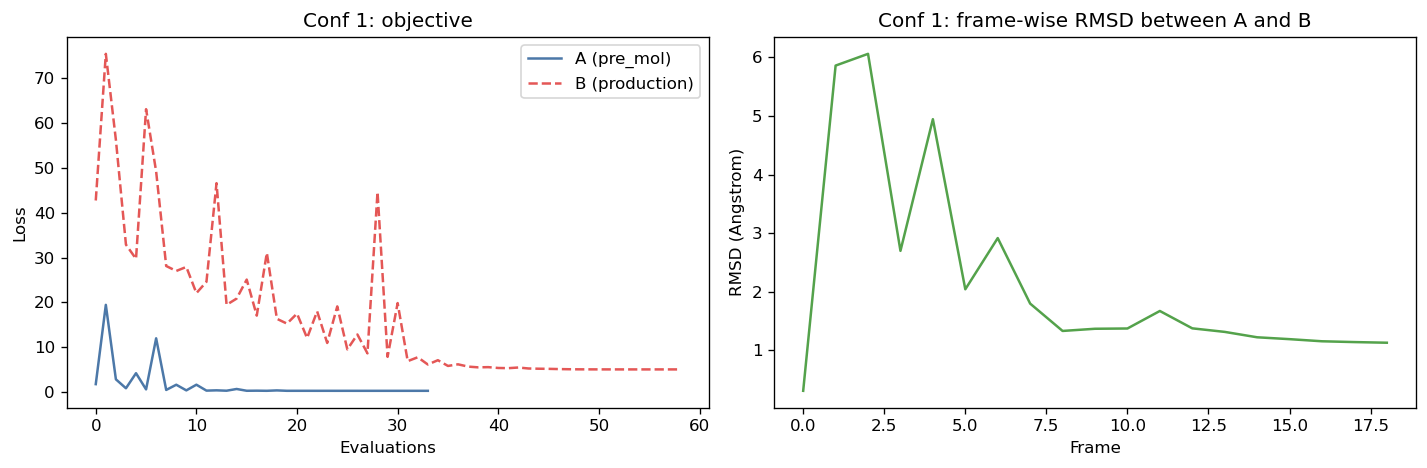

In [14]:
plot_trajectory_comparison(1)

## Export trajectories to SDF

In [ ]:
def _mol_with_replaced_ring(
    mol_template: Chem.Mol, ring_idxs: List[int], ring_xyz: np.ndarray
) -> Chem.Mol:
    conf = Chem.Conformer(mol_template.GetConformer(0))
    for atom_idx, pos in zip(ring_idxs, np.asarray(ring_xyz, dtype=float)):
        conf.SetAtomPosition(
            int(atom_idx), [float(pos[0]), float(pos[1]), float(pos[2])]
        )
    new_mol = Chem.Mol(mol_template, quickCopy=True)
    new_mol.RemoveAllConformers()
    new_mol.AddConformer(conf, assignId=True)
    return new_mol


def export_trajectory_sdf(
    base_mol: Chem.Mol,
    traj: TrajectoryResult,
    ring_idxs: List[int],
    out_path: Path,
    method: str = "",
) -> Path:
    mol_template = Chem.Mol(base_mol, quickCopy=True)
    mol_template.RemoveAllConformers()
    mol_template.AddConformer(Chem.Conformer(base_mol.GetConformer(0)), assignId=True)

    writer = Chem.SDWriter(str(out_path))
    for step_idx, ring_xyz in enumerate(traj.ring_xyz_frames):
        mol_step = _mol_with_replaced_ring(mol_template, ring_idxs, ring_xyz)
        mol_step.SetProp("conf_idx", str(traj.conf_idx))
        mol_step.SetProp("opt_step", str(step_idx))
        mol_step.SetProp("n_frames", str(len(traj.ring_xyz_frames)))
        mol_step.SetProp("method", method)
        writer.write(mol_step)
    writer.close()
    return out_path


OUT_DIR = ROOT / "sample/analysis/optimization_trajectory/comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

mol_stem = Path(MOL_NAME).stem
for conf_idx in conf_indices:
    export_trajectory_sdf(
        base_mol=pre_mol,
        traj=results_A[conf_idx],
        ring_idxs=ring_idxs,
        out_path=OUT_DIR / f"{mol_stem}_conf{conf_idx}_A_premol.sdf",
        method="A_premol",
    )
    export_trajectory_sdf(
        base_mol=test_mol,
        traj=results_B[conf_idx],
        ring_idxs=ring_idxs,
        out_path=OUT_DIR / f"{mol_stem}_conf{conf_idx}_B_production.sdf",
        method="B_production",
    )

print(f"Exported {len(conf_indices) * 2} SDF files to {OUT_DIR}")

Exported 64 SDF files to /mnt/HDD1/Codes/ringer/sample/analysis/optimization_trajectory/comparison


In [18]:
pre_mol

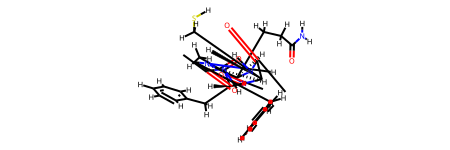

In [19]:
mol_B

In [22]:
import py3Dmol

# pre_mol conformer 0 with canonical transform
xyz0_raw = pre_mol.GetConformer(0).GetPositions()[ring_idxs]
trans_mat = compute_canonical_transform(xyz0_raw)
xyz0_canonical = apply_affine_transform(xyz0_raw, trans_mat)
mol_canonical = _mol_with_replaced_ring(pre_mol, ring_idxs, xyz0_canonical)

mb_a = Chem.MolToMolBlock(mol_canonical)
viewer_a = py3Dmol.view(width=600, height=400)
viewer_a.addModel(mb_a, "mol")
viewer_a.setStyle({"stick": {}, "sphere": {"radius": 0.3}})
viewer_a.zoomTo()
print("Method A: pre_mol conf 0 (canonical transform applied)")
viewer_a.show()

Method A: pre_mol conf 0 (canonical transform applied)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.